In [1]:
import os
from dotenv import load_dotenv, find_dotenv
from src.modules.workflow_manager import GraphBuilder
from src.rags.self_rag import get_self_rag_graph
from src.rags.crag import get_crag_graph
from src.rags.basic_rag import get_basic_rag_graph
from src2.workflow_manager import build_seal_rag_graph

# Automatically find and load the .env file
#dotenv_path = find_dotenv()
load_dotenv("./.env")

graph = build_seal_rag_graph()
#graph= get_self_rag_graph()
#graph= get_crag_graph()
#graph = get_basic_rag_graph()

print("done")

/opt/homebrew/anaconda3/envs/langgraph_v1/lib/python3.11/site-packages/pinecone/data/index.py:1: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm
/var/folders/8g/yk7b34915s1b5qdl5nc6twm40000gn/T/ipykernel_92707/3274371194.py:4: LangChainDeprecationWarning: As of langchain-core 0.3.0, LangChain uses pydantic v2 internally. The langchain_core.pydantic_v1 module was a compatibility shim for pydantic v1, and should no longer be used. Please update the code to import from Pydantic directly.

For example, replace imports like: `from langchain_core.pydantic_v1 import BaseModel`
with: `from pydantic import BaseModel`
or the v1 compatibility namespace if you are working in a code base that has not been fully upgraded to pydantic 2 yet. 	from pydantic.v1 import BaseModel

  from src.rags.self_rag import get_self_rag_graph
/opt/homebrew/anaconda3/envs/langgraph_v1/lib/pyth

done


/opt/homebrew/anaconda3/envs/langgraph_v1/lib/python3.11/site-packages/langchain_openai/chat_models/base.py:1844: UserWarning: Received a Pydantic BaseModel V1 schema. This is not supported by method="json_schema". Please use method="function_calling" or specify schema via JSON Schema or Pydantic V2 BaseModel. Overriding to method="function_calling".
  warnings.warn(
/opt/homebrew/anaconda3/envs/langgraph_v1/lib/python3.11/site-packages/langchain_openai/chat_models/base.py:1844: UserWarning: Received a Pydantic BaseModel V1 schema. This is not supported by method="json_schema". Please use method="function_calling" or specify schema via JSON Schema or Pydantic V2 BaseModel. Overriding to method="function_calling".
  warnings.warn(
/opt/homebrew/anaconda3/envs/langgraph_v1/lib/python3.11/site-packages/langchain_openai/chat_models/base.py:1844: UserWarning: Received a Pydantic BaseModel V1 schema. This is not supported by method="json_schema". Please use method="function_calling" or speci

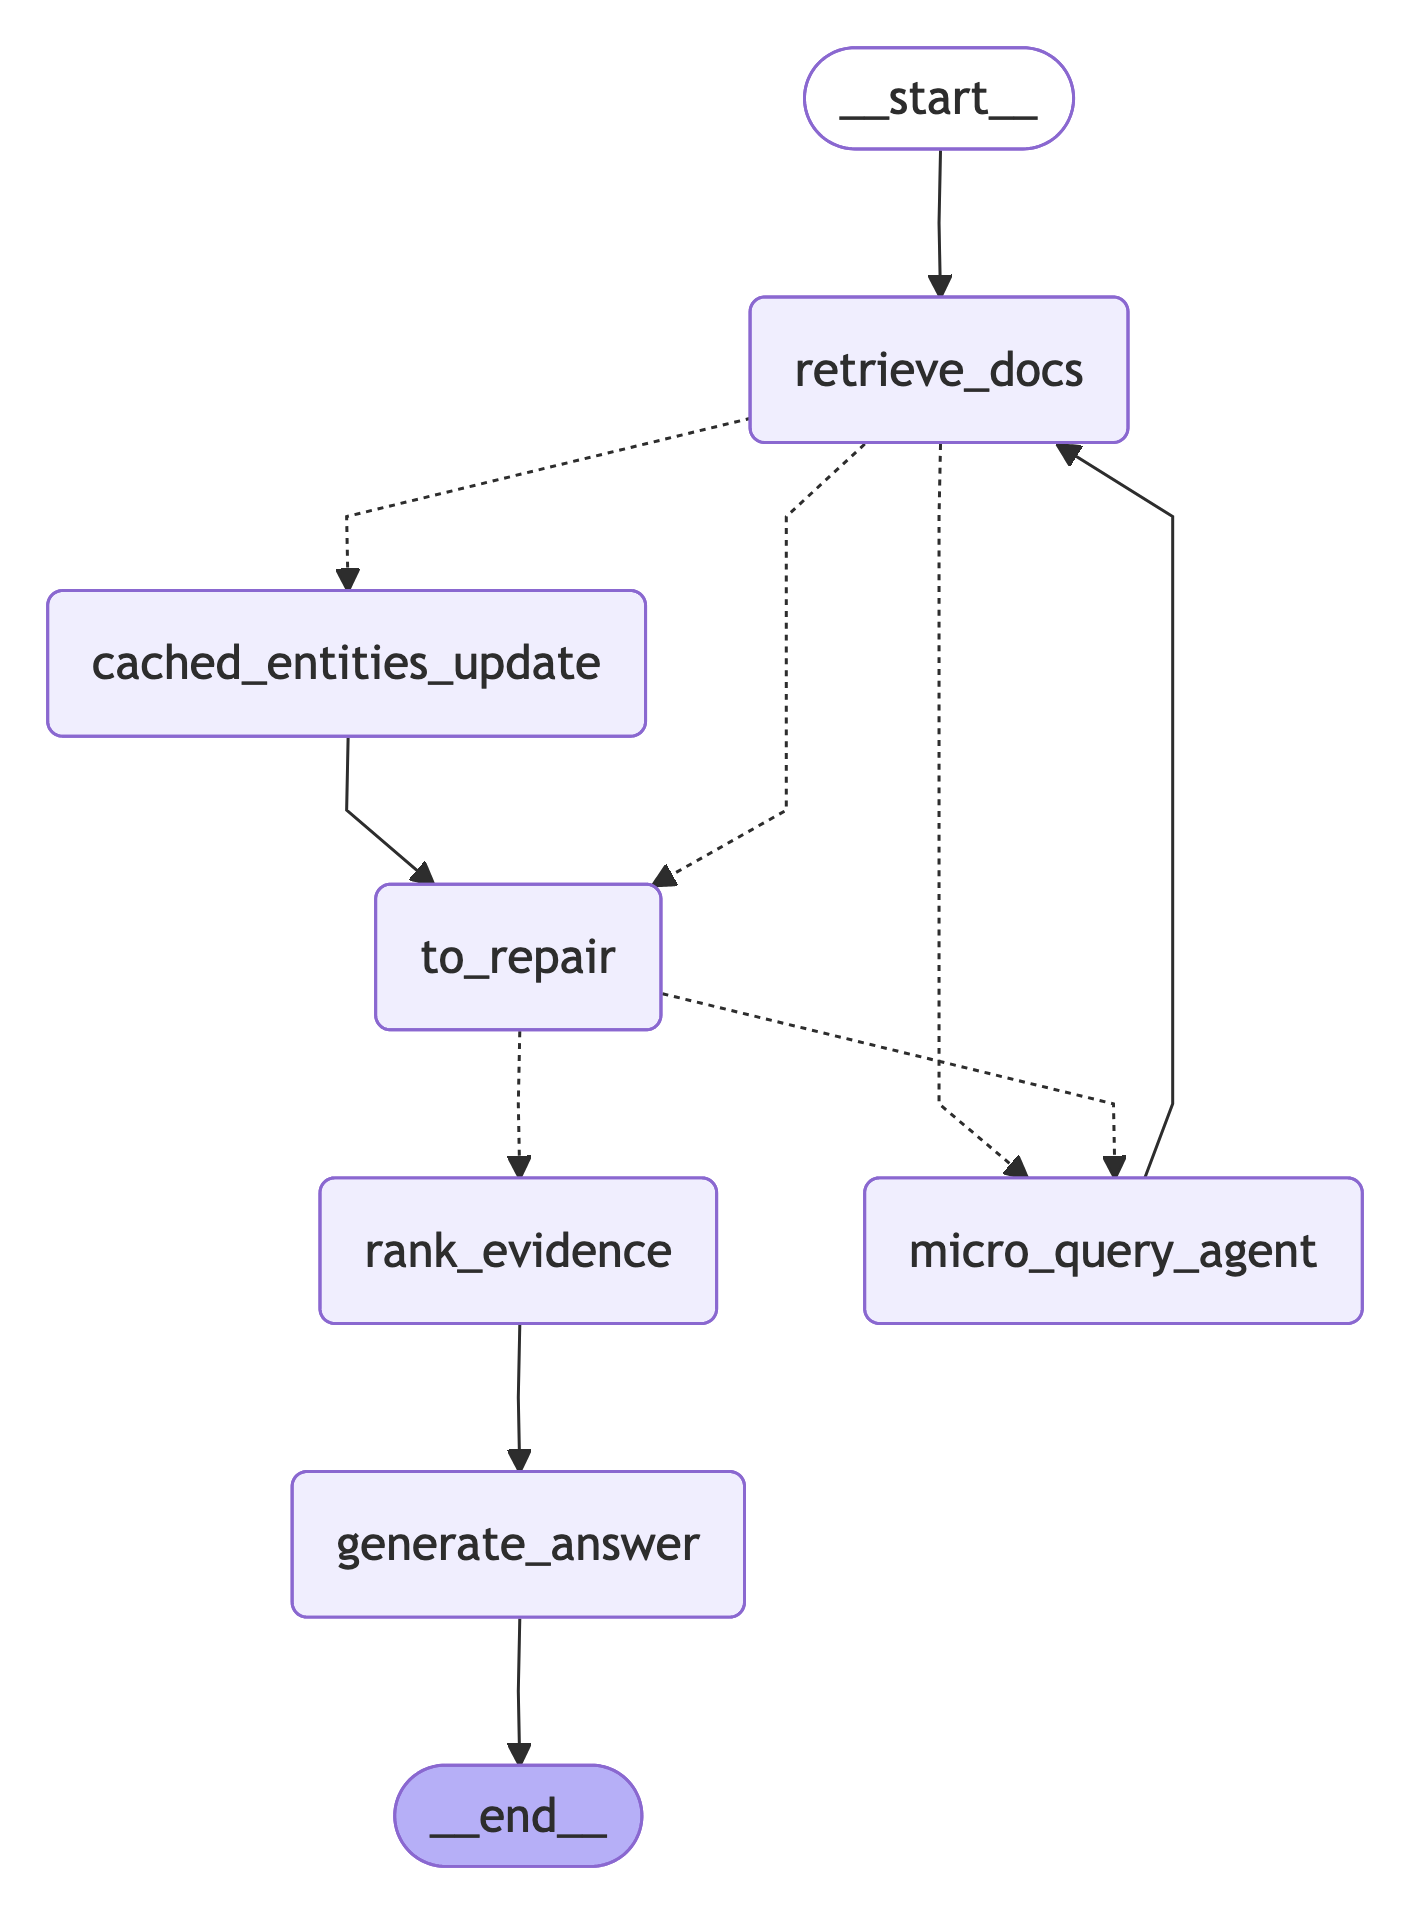

In [2]:
import nest_asyncio
nest_asyncio.apply()  # Allows nested event loops in Jupyter

from IPython.display import Image, display
from langchain_core.runnables.graph import Graph, MermaidDrawMethod


# Render the graph as a PNG image using the local pyppeteer renderer
image_bytes = graph.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.PYPPETEER)

# Display the image in the notebook
display(Image(data=image_bytes))

In [3]:
from datasets import load_dataset
#from langcloud import Client  # or from 
from langsmith import Client
from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
import os
import asyncio
import ast



# ----------------------------
# 1. Create simple LangChain correctness evaluator
# ----------------------------

class EvaluationResult(BaseModel):
    """Evaluation result with reasoning and score."""
    reasoning: str = Field(
        ...,
        description="short explanation of why the answer is correct or incorrect"
    )
    score: bool = Field(
        ...,
        description="True if the answer is correct, False if incorrect"
    )

# Correctness evaluation prompt
correctness_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are an expert data labeler evaluating model outputs for correctness. Your task is to assign a score based on the following rubric:

<Rubric>
  A correct answer:
  - Provides accurate and complete information that matches the ground truth
  - Contains no factual errors when compared to the reference
  - Addresses the core question being asked
  - Is logically consistent with the expected answer
  - Uses precise and accurate terminology
  - May be phrased differently but conveys the same essential meaning as the ground truth

  When scoring, you should penalize:
  - Factual errors or inaccuracies compared to ground truth
  - Answers that contradict the reference output
  - Misleading or ambiguous statements that deviate from truth
  - Completely incorrect or irrelevant responses
  - Missing key information that changes the meaning
  - "I don't know" responses when ground truth provides a clear answer
</Rubric>

<Instructions>
  - Carefully compare the agent's output against the ground truth reference
  - Focus on semantic equivalence rather than exact word matching
  - Consider that correct answers may be expressed in different ways
  - Evaluate factual accuracy and alignment with the expected answer
  - Be lenient with minor phrasing differences if the core meaning matches
  - Be strict with factual contradictions or completely wrong information
</Instructions>

<Reminder>
  The goal is to evaluate how well the agent's final answer aligns with the ground truth, focusing on factual correctness and semantic equivalence rather than exact textual match.
</Reminder>"""),
    ("human", """<question>
{question}
</question>

<agent_output>
{agent_answer}
</agent_output>

<ground_truth>
{ground_truth}
</ground_truth>

Compare the agent's output against the ground truth and evaluate its correctness. Provide your reasoning and a boolean score (true for correct, false for incorrect).""")
])

# Create LLM for evaluation
eval_llm = ChatOpenAI(model="gpt-4o", temperature=0)
structured_eval_llm = eval_llm.with_structured_output(EvaluationResult)

# Create evaluation chain
correctness_evaluator = correctness_prompt | structured_eval_llm



# ----------------------------
# 2. run_graph with progress print
# ----------------------------
async def run_graph(inputs: dict) -> dict:
   
    # Call your RAG graph (replace with your real invocation)
    result = await graph.ainvoke(
        {"user_query": inputs["question"]},
        config={"env": "test", "configurable": {"thread_id": 130}, "recursion_limit": 100}
    )

#    docs = result.get("documents", [])
#    docs = result.get("relevance_documents", "documents")
    docs = result.get("relevance_documents") or result.get("documents", [])


    print(f"docs length: {len(docs) }")

    retrieved = [d.page_content for d in docs]

    #answer = result.get("final_answer", "generation")
    answer = result.get("final_answer") or result.get("generation", "")
    
    return {
        "response":     answer,
        "retrieved_docs_list": retrieved,
        # If your graph later populates docs_to_use, include it in the outputs too
        "docs_to_use":  result.get("docs_to_use", retrieved),
    }

# ----------------------------
# 3. Correctness evaluator wrapper
# ----------------------------
def final_answer_correct(inputs, outputs, reference_outputs) -> bool:
    # Use the LangChain evaluator with structured output
    result = correctness_evaluator.invoke({
        "question": inputs["question"],
        "agent_answer": outputs["response"],
        "ground_truth": reference_outputs["answer"]
    })
    # result is already an EvaluationResult object
    return result.score




# 5. IR‐metric evaluator: Precision@k, Recall@k, F1@k
# ----------------------------

def retrieval_metrics_with_f1(inputs, outputs, reference_outputs) -> list[dict]:
    # parse gold titles
    sf = ast.literal_eval(inputs["supporting_facts"])
    gold = set(sf["title"])

    # normalize & dedupe your retrieved docs
    #retrieved_raw = outputs.get("docs_to_use", outputs["retrieved_docs_list"])
    retrieved_raw = outputs.get("docs_to_use")
    if not retrieved_raw:
        retrieved_raw = outputs.get("docs_to_explain")
    if not retrieved_raw:
        retrieved_raw = outputs.get("retrieved_docs_list", [])


    seen, deduped = set(), []
    for doc in retrieved_raw:
        text = getattr(doc, "page_content", None) or getattr(doc, "content", None) or str(doc)
        title = text.split(":", 1)[0].strip()
        if title not in seen:
            seen.add(title)
            deduped.append(title)

    # true positives
    tp = len(gold & set(deduped))

    # precision (relevance_rate) and recall
    precision = tp / len(deduped)   if deduped else 0.0
    recall    = tp / len(gold)      if gold    else 0.0

    # F1
    if precision + recall > 0:
        f1 = 2 * (precision * recall) / (precision + recall)
    else:
        f1 = 0.0

    return [
        {"key": "precision",      "score": precision},
        {"key": "recall",         "score": recall},
        {"key": "f1",             "score": f1},
    ]
# ----------------------------
# 5. Assemble and run the experiment
# ----------------------------
client = Client(api_key=os.environ["LANGCHAIN_API_KEY"])


results = await client.aevaluate(
    run_graph,
    data="HotpotQA_1000_validation_hard_v1",
    evaluators=[final_answer_correct, retrieval_metrics_with_f1],
    experiment_prefix="seal_rag_k_1_model_gpt-4.1_max_loop_3_v_8",
    num_repetitions=1,
    max_concurrency=5,
)
df = results.to_pandas()
df




View the evaluation results for experiment: 'seal_rag_k_1_model_gpt-4.1_max_loop_3_v_8-fec16bc4' at:
https://smith.langchain.com/o/b77e783a-1e93-40c4-975b-317ef061487f/datasets/afd42653-e95e-45da-9ec0-73cd75b4a4f3/compare?selectedSessions=67e71d60-172b-4bde-8e0c-433a8f547f45




0it [00:00, ?it/s]

---RETRIEVE---
---RETRIEVE---
---RETRIEVE---
---RETRIEVE---
---RETRIEVE---
---CONTINUE TO CACHED ENTITIES UPDATE AGENT------CONTINUE TO CACHED ENTITIES UPDATE AGENT---
Dispatching 1 documents for cached entities extraction
Original query: When was Poison's album "Shut Up, Make Love" released?
Micro query: None
Created 1 Send commands for parallel processing
---CONTINUE TO CACHED ENTITIES UPDATE AGENT---
Dispatching 1 documents for cached entities extraction
Original query: Who runs the website surpassed by both Baidu Baike and Hudong.com?
Micro query: None
Created 1 Send commands for parallel processing

Dispatching 1 documents for cached entities extraction
Original query: The 2011–12 VCU Rams men's basketball team, led by third year head coach Shaka Smart, represented Virginia Commonwealth University which was founded in what year?
Micro query: None
Created 1 Send commands for parallel processing
---CACHED ENTITIES UPDATE (SimpleTriplet)---
Extracting triplets from document (dynamic 

1it [00:19, 19.75s/it]

---RETRIEVE---
Decision: yes
Reasoning: 1. QUERY DECOMPOSITION: The core question is: In what year was Virginia Commonwealth University (VCU) founded? The query is well-formed and asks for a specific attribute (founding year) of a unique entity (VCU). Scope is 'the' (specific), so a unique, explicit value is required.

2. PATH DISCOVERY: The starting entity is Virginia Commonwealth University. The attribute sought is the founding year. ...
---ROUTING AFTER REPAIR DECISION---
✅ Ready to answer - proceeding to rank_evidence
---RANK EVIDENCE---
---GENERATE---
---CONTINUE TO CACHED ENTITIES UPDATE AGENT---
Dispatching 1 documents for cached entities extraction
Original query: What's the name of the fantasy film starring Sarah Bolger, featuring a New England family who discover magical creatures around their estate?
Micro query: None
Created 1 Send commands for parallel processing
---CACHED ENTITIES UPDATE (SimpleTriplet)---
Extracting triplets from document (dynamic focus)...
Decision: yes

...

---CONTINUE TO CACHED ENTITIES UPDATE AGENT---
Dispatching 1 documents for cached entities extraction
Original query: Mick Carter is the landlord of a public house located at what address?
Micro query: address location The Queen Victoria pub EastEnders
Created 1 Send commands for parallel processing
---CACHED ENTITIES UPDATE (SimpleTriplet)---
Extracting triplets from document (dynamic focus)...


999it [1:19:29,  2.56s/it]

---TO REPAIR?---
Evaluating repair decision with 2 cached entities and 2 documents
Making repair decision with LLM...
Decision: yes
Reasoning: 1. QUERY DECOMPOSITION: The question asks for the address of the public house where Mick Carter is landlord. It is specific ('the landlord of a public house located at what address?'), so a unique, unambiguous chain is required. Attribute intent=True (location/address).

2. PATH DISCOVERY: Starting entity is Mick Carter. Entities and documents confirm: Mick Carter → landlord_of → The Queen Victori...
---ROUTING AFTER REPAIR DECISION---
✅ Ready to answer - proceeding to rank_evidence
---RANK EVIDENCE---
---GENERATE---
docs length: 2


1000it [1:19:40,  4.78s/it]


,inputs.context,inputs.question,inputs.supporting_facts,outputs.response,outputs.retrieved_docs_list,outputs.docs_to_use,error,reference.answer,feedback.final_answer_correct,feedback.precision,feedback.recall,feedback.f1,execution_time,example_id,id
0,"{'title': ['Alle tiders kupp', 'Vinmonopolet',...",Carlos Salazar Lomelín is the CEO of which Mex...,"{'title': ['Carlos Salazar Lomelín', 'FEMSA'],...",Coca-Cola FEMSA,[Carlos Salazar Lomelín: Carlos Salazar Lomelí...,[Carlos Salazar Lomelín: Carlos Salazar Lomelí...,None,Fomento Económico Mexicano,False,1.0,0.5,0.666667,17.045559,0169d92a-754a-407c-afd8-5372b4b493a5,49115f0a-e32c-473b-9e02-0fae8af530bc
1,"{'title': [""2012–13 VCU Rams men's basketball ...","The 2011–12 VCU Rams men's basketball team, le...","{'title': [""2011–12 VCU Rams men's basketball ...",1838,[Virginia Commonwealth University: Virginia Co...,[Virginia Commonwealth University: Virginia Co...,None,1838,True,1.0,0.5,0.666667,22.021974,009df37c-3a8f-4a00-b8ed-342f7754257e,3f274aeb-b5eb-41d4-954d-6e4b5b4fa534
2,"{'title': ['Baidu Baike', 'Social Networking a...",Who runs the website surpassed by both Baidu B...,"{'title': ['Baidu Baike', 'Chinese Wikipedia',...",Wikimedia Foundation,[Chinese Wikipedia: The Chinese Wikipedia () i...,[Chinese Wikipedia: The Chinese Wikipedia () i...,None,Wikimedia Foundation,True,1.0,0.5,0.666667,23.072820,016dfba5-d311-462a-8ce5-c9db85d2159e,75810acc-c975-4fcf-9ab9-72f60bdc9129
3,"{'title': ['Clayton Oliver', 'Stephen Coniglio...",What is the height of the player who won the 2...,"{'title': ['2015 AFL Rising Star', 'Jesse Hoga...",I don't know.,[2015 AFL Rising Star: The NAB AFL Rising Star...,[2015 AFL Rising Star: The NAB AFL Rising Star...,None,1.95 m,False,1.0,0.5,0.666667,26.306886,0004211d-fdd0-46a4-ba01-3a5d916924e9,0ea5b9e9-261d-48d2-a002-989455b6f7a0
4,"{'title': ['Magic in Harry Potter', 'Sinbad of...",What's the name of the fantasy film starring S...,"{'title': ['Sarah Bolger', 'The Spiderwick Chr...",The Spiderwick Chronicles,[The Spiderwick Chronicles (film): The Spiderw...,[The Spiderwick Chronicles (film): The Spiderw...,None,The Spiderwick Chronicles,True,1.0,0.5,0.666667,11.989169,01cd7445-ef49-416d-b27a-d3082ac9152a,dd568fd2-3725-4562-a44c-fb439f15c5f1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,"{'title': ['Delmer Daves', 'Dark Passage (film...","Who has more scope of profession, Phil Rosen o...","{'title': ['Delmer Daves', 'Phil Rosen'], 'sen...",Delmer Daves,"[Delmer Daves: Delmer Lawrence Daves (July 24,...","[Delmer Daves: Delmer Lawrence Daves (July 24,...",None,Delmer Lawrence Daves,True,1.0,1.0,1.000000,26.010052,fd316438-a158-4f1a-9414-f27ede1082e8,ffe7bdc3-eacd-4523-820d-176c152a6c51
996,"{'title': [""2015 Rogers Cup – Women's Doubles""...","Who had the best singles ranking, Roberta Vinc...","{'title': ['Roberta Vinci', 'Roberta Vinci', '...",Roberta Vinci,[Jorge Lozano: Jorge Lozano (born 17 May 1963 ...,[Jorge Lozano: Jorge Lozano (born 17 May 1963 ...,None,Roberta Vinci,True,1.0,1.0,1.000000,16.658582,feab479e-056d-4066-9cf8-b687d34398b0,23bdafbc-8e2b-4feb-8881-5383b5389f83
997,"{'title': ['Archdeaconry of St Andrews', 'St D...",St Dionis Backchurch was rebuilt after a major...,"{'title': ['St Dionis Backchurch', 'St Dionis ...",Eighty-eight parish churches,[St Dionis Backchurch: St Dionis Backchurch wa...,[St Dionis Backchurch: St Dionis Backchurch wa...,None,87,False,0.5,0.5,0.500000,22.894136,fdf4d662-d51a-4c36-a798-e5f9bc5bcc38,1d5b90f2-d25f-4331-965b-48776b7ea4b8
998,"{'title': ['Lana Del Rey (EP)', 'Back to Decem...","Yoann Lemoine, a French video director, has cr...","{'title': ['Yoann Lemoine', 'Yoann Lemoine', '...",Taylor Swift,[Yoann Lemoine: Yoann Lemoine (born 16 March 1...,[Yoann Lemoine: Yoann Lemoine (born 16 March 1...,None,Taylor Swift,True,1.0,0.5,0.666667,10.551824,ff316509-701e-4e84-ae05-17e9b2b3c080,19e36131-3920-4dc2-8648-966794b7a012


In [9]:
df.head()

,inputs.context,inputs.question,inputs.supporting_facts,outputs.response,outputs.retrieved_docs_list,outputs.docs_to_use,error,reference.answer,feedback.final_answer_correct,feedback.precision,feedback.recall,feedback.f1,execution_time,example_id,id,outputs.output,feedback.wrapper
0,"{'title': ['Enda Kenny', 'Fine Gael leadership...","Since 2 June 2017, The Leader of Fine Gael had...","{'title': ['Leader of Fine Gael', 'Leo Varadka...","Since 2 June 2017, the Leader of Fine Gael has...",[Enda Kenny: Enda Patrick Kenny (born 24 April...,[Enda Kenny: Enda Patrick Kenny (born 24 April...,None,Leo Varadkar,True,0.666667,1.0,0.8,7.662598,01890c6a-a3ea-4cf0-8514-e469c2e46032,c2757b21-dc5b-4eb6-b8c7-f3ce4c19d7eb,NaN,NaN
1,"{'title': ['Ralph Charles', 'Bunny Grant', 'Vi...",Vince Phillips held a junior welterweight titl...,"{'title': ['Vince Phillips', 'International Bo...",The larger Hall of Fame that recognizes the In...,[International Boxing Federation: The Internat...,[International Boxing Federation: The Internat...,None,International Boxing Hall of Fame,True,0.500000,0.5,0.5,10.946834,0354d139-82d6-416d-a698-99b070598b57,c4b3a1fb-4382-4db9-9fe4-8bbb68435e58,NaN,NaN
2,"{'title': ['2009 Singapore Grand Prix', 'Catha...",Which other Mexican Formula One race car drive...,"{'title': ['Formula One drivers from Mexico', ...","The other Mexican Formula One driver, besides ...",[Formula One drivers from Mexico: There have b...,[Formula One drivers from Mexico: There have b...,None,Pedro Rodríguez,True,0.500000,0.5,0.5,12.259177,04dd6118-3990-48ef-9d5f-18dec47283fe,b54edfec-8a0f-477e-a060-ed7d917df44e,NaN,NaN
3,"{'title': [""It's Alive! (Dexter)"", 'Hello, Dex...",Who were the directors of the 2009 American sc...,"{'title': ['Gamer (film)', 'Michael C. Hall'],...","The 2009 American sci-fi film ""Gamer,"" featuri...",[Gamer is a 2009 American science fiction acti...,[Gamer is a 2009 American science fiction acti...,None,Mark Neveldine and Brian Taylor,True,0.000000,0.0,0.0,11.559350,032e3f0c-7622-4ae7-a0be-49361a664c60,6503595b-dbca-4851-a91e-2f1a24b3aa2c,NaN,NaN
4,"{'title': ['Maltin on Movies', 'Comedy Film Ne...",What podcast was the cheif executive officer o...,"{'title': ['Comedy Film Nerds', 'Comedy Film N...","The CEO of Nerdist Industries, Chris Hardwick,...","[Founder, CEO and creative head of Nerdist Ind...","[Founder, CEO and creative head of Nerdist Ind...",None,Comedy Film Nerds,False,0.000000,0.0,0.0,12.506101,011e87e0-185f-4dcc-8cce-2d6dde0fca2c,76667303-f433-4bc9-92b8-cf96be348738,NaN,NaN


In [11]:
df.iloc[0]

inputs.context                   {'title': ['Enda Kenny', 'Fine Gael leadership...
inputs.question                  Since 2 June 2017, The Leader of Fine Gael had...
inputs.supporting_facts          {'title': ['Leader of Fine Gael', 'Leo Varadka...
outputs.response                 Since 2 June 2017, the Leader of Fine Gael has...
outputs.retrieved_docs_list      [Enda Kenny: Enda Patrick Kenny (born 24 April...
outputs.docs_to_use              [Enda Kenny: Enda Patrick Kenny (born 24 April...
error                                                                         None
reference.answer                                                      Leo Varadkar
feedback.final_answer_correct                                                 True
feedback.precision                                                        0.666667
feedback.recall                                                                1.0
feedback.f1                                                                    0.8
exec